<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/pid_datasheet_to_cad_cfd_neqsim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# P&ID and datasheet to CAD and CFD with NeqSim

This notebook turns a reviewed, structured P&ID and mechanical/process
datasheet into a traceable engineering workflow:

1. preserve equipment, stream, nozzle, and instrument tags;
2. calculate a three-phase inlet state with NeqSim;
3. generate an exact gas-space B-Rep with CadQuery;
4. retain named CFD boundaries through Gmsh;
5. run a real OpenFOAM gas-space RANS screen;
6. render the actual CAD, mesh, and solved fields; and
7. package the normalized design basis with the reusable artifacts.

The example data are synthetic and non-proprietary. The OpenFOAM model is a
single-gas-phase hydraulic screen above a fixed liquid interface. It is not a
multiphase separator-performance or equipment-qualification model.

## Workflow and engineering boundary

| Stage | Authoritative input | Output |
|---|---|---|
| Document normalization | reviewed P&ID and datasheets | tagged JSON design basis |
| Image QA | calibrated measurement record | dimensional discrepancy flag |
| Thermodynamics | process datasheet | NeqSim phase split and gas properties |
| CAD | approved mechanical dimensions | exact gas-space STEP and named STL |
| Meshing | STEP master | Gmsh tetrahedra and physical groups |
| CFD | NeqSim gas boundary data | OpenFOAM velocity, pressure, and turbulence |
| Feedback | solved field checks | pressure loss and residence-time screen |

A photograph is not treated as dimensional authority unless it contains a
reliable scale reference and has been corrected for perspective. In this
demonstration it is only an independent consistency check.

## 1. Clean-runtime setup

The setup uses pinned Python packages and OpenFOAM Foundation 14. In Colab,
the installation is retained only for the current runtime.

In [1]:
import ctypes.util
import importlib.util
import os
from pathlib import Path
import shlex
import subprocess
import sys


PYTHON_REQUIREMENTS = {
    "cadquery": "cadquery==2.6.1",
    "gmsh": "gmsh==4.15.0",
    "meshio": "meshio==5.3.5",
    "neqsim": "neqsim==3.16.0",
    "pyvista": "pyvista==0.46.4",
}

system_library_override = os.environ.get("CAD_SYSTEM_LIBRARY_OVERRIDE")
if not system_library_override and ctypes.util.find_library("GLU") is None:
    system_setup = r'''
set -euo pipefail
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq libglu1-mesa
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq libxft2 libopengl0
'''
    subprocess.run(
        ["bash", "-lc", system_setup],
        check=True,
    )

missing_requirements = [
    requirement
    for module, requirement in PYTHON_REQUIREMENTS.items()
    if importlib.util.find_spec(module) is None
]
if missing_requirements:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *missing_requirements,
        ]
    )

openfoam_override = os.environ.get("OPENFOAM_ROOT_OVERRIDE")
default_openfoam_root = Path("/opt/openfoam14")

if openfoam_override and Path(openfoam_override).is_dir():
    OPENFOAM_ROOT = Path(openfoam_override)
elif default_openfoam_root.is_dir():
    OPENFOAM_ROOT = default_openfoam_root
else:
    install_openfoam = r'''
set -euo pipefail
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq ca-certificates
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq software-properties-common
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq wget
wget -qO /etc/apt/trusted.gpg.d/openfoam.asc https://dl.openfoam.org/gpg.key
rm -f /etc/apt/sources.list.d/*dl_openfoam_org*list
add-apt-repository -y "http://dl.openfoam.org/ubuntu main dev"
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq openfoam14
'''
    subprocess.run(
        ["bash", "-lc", install_openfoam],
        check=True,
    )
    OPENFOAM_ROOT = default_openfoam_root

foam_run_candidates = list(
    OPENFOAM_ROOT.glob("platforms/*/bin/foamRun")
)
if len(foam_run_candidates) != 1:
    raise RuntimeError("A unique OpenFOAM foamRun binary was not found")

OPENFOAM_PLATFORM = foam_run_candidates[0].parent.parent.name
print("Python dependencies are available.")
print(f"OpenFOAM root: {OPENFOAM_ROOT}")
print(f"OpenFOAM platform: {OPENFOAM_PLATFORM}")

Python dependencies are available.
OpenFOAM root: /workspace/scratch/414b0104c46c/.openfoam-root/opt/openfoam14
OpenFOAM platform: linux64GccDPInt32Opt


## 2. Imports, versions, and deterministic workspace

All generated files are kept below one runtime directory so the complete
digital thread can be downloaded at the end.

In [2]:
from importlib.metadata import version
import json
import math
import re
import shutil

import cadquery as cq
import gmsh
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import pandas as pd
import pyvista as pv

from neqsim import jneqsim


RUNTIME_PARENT = (
    Path("/content")
    if Path("/content").is_dir()
    else Path.cwd()
)
RUNTIME_DIR = RUNTIME_PARENT / "pid_datasheet_cfd_runtime"
if RUNTIME_DIR.is_dir():
    shutil.rmtree(RUNTIME_DIR)

GEOMETRY_DIR = RUNTIME_DIR / "geometry"
CASE_DIR = RUNTIME_DIR / "openfoam_case"
GEOMETRY_DIR.mkdir(parents=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.6g}")

versions = pd.Series(
    {
        "NeqSim": version("neqsim"),
        "CadQuery": version("cadquery"),
        "Gmsh": version("gmsh"),
        "PyVista": version("pyvista"),
        "Python": sys.version.split()[0],
        "OpenFOAM": "Foundation 14",
    },
    name="validated software",
)
versions

NeqSim             3.16.0
CadQuery            2.6.1
Gmsh               4.15.0
PyVista            0.46.4
Python            3.12.13
OpenFOAM    Foundation 14
Name: validated software, dtype: str

## 3. Normalize the P&ID and datasheets

The normalized design basis records every value with a source, confidence,
and review status. The P&ID supplies connectivity and tags. The mechanical
datasheet supplies dimensions. The process datasheet supplies the fluid
state and composition.

The vessel is intentionally simple: a horizontal cylinder with hemispherical
heads, an axial gas inlet and outlet, and a fixed horizontal liquid interface.

In [3]:
DOCUMENT_MODEL = {
    "metadata": {
        "equipment_tag": "20-VG-001",
        "revision": "A",
        "status": "synthetic educational data",
        "dimensional_authority": "mechanical_datasheet",
    },
    "pid": {
        "inlet_stream_tag": "20-P-001",
        "gas_outlet_stream_tag": "20-P-002",
        "liquid_outlet_stream_tag": "20-P-003",
        "pressure_control_tag": "20-PIC-001",
        "level_control_tag": "20-LIC-001",
    },
    "mechanical_datasheet": {
        "vessel_inside_diameter_m": 2.40,
        "tangent_length_m": 7.20,
        "head_type": "hemispherical",
        "liquid_level_from_bottom_m": 0.75,
        "inlet_nozzle_inside_diameter_m": 0.3048,
        "outlet_nozzle_inside_diameter_m": 0.2540,
        "nozzle_center_elevation_m": 0.45,
        "inlet_external_x_m": -1.65,
        "inlet_internal_x_m": -0.80,
        "outlet_internal_x_m": 8.00,
        "outlet_external_x_m": 8.85,
    },
    "process_datasheet": {
        "temperature_c": 45.0,
        "pressure_bara": 65.0,
        "total_mass_flow_kg_per_h": 120_000.0,
        "composition_mole_fraction": {
            "nitrogen": 0.007,
            "CO2": 0.020,
            "methane": 0.720,
            "ethane": 0.070,
            "propane": 0.050,
            "i-butane": 0.015,
            "n-butane": 0.020,
            "i-pentane": 0.010,
            "n-pentane": 0.010,
            "n-hexane": 0.020,
            "n-heptane": 0.020,
            "n-octane": 0.015,
            "water": 0.023,
        },
    },
    "calibrated_image_qa": {
        "status": "synthetic measurement record",
        "reference": "inlet nozzle inside diameter",
        "reference_length_m": 0.3048,
        "reference_pixels": 152.4,
        "vessel_inside_diameter_pixels": 1_202.0,
        "acceptance_relative": 0.02,
    },
}

DESIGN_BASIS_PATH = RUNTIME_DIR / "engineering_design_basis.json"
DESIGN_BASIS_PATH.parent.mkdir(parents=True, exist_ok=True)
DESIGN_BASIS_PATH.write_text(
    json.dumps(
        DOCUMENT_MODEL,
        indent=2,
    )
)

mechanical = DOCUMENT_MODEL["mechanical_datasheet"]
image_qa = DOCUMENT_MODEL["calibrated_image_qa"]
pixels_per_metre = (
    image_qa["reference_pixels"]
    / image_qa["reference_length_m"]
)
image_vessel_diameter_m = (
    image_qa["vessel_inside_diameter_pixels"]
    / pixels_per_metre
)
datasheet_vessel_diameter_m = (
    mechanical["vessel_inside_diameter_m"]
)
image_dimension_deviation_relative = abs(
    image_vessel_diameter_m
    - datasheet_vessel_diameter_m
) / datasheet_vessel_diameter_m

assert DOCUMENT_MODEL["metadata"]["status"] == (
    "synthetic educational data"
)
assert image_dimension_deviation_relative < (
    image_qa["acceptance_relative"]
)

traceability_table = pd.DataFrame(
    [
        {
            "parameter": "equipment identity",
            "value": DOCUMENT_MODEL["metadata"]["equipment_tag"],
            "source": "P&ID",
            "confidence": "high",
            "review": "accepted",
        },
        {
            "parameter": "vessel inside diameter",
            "value": f"{datasheet_vessel_diameter_m:.3f} m",
            "source": "mechanical datasheet",
            "confidence": "high",
            "review": "accepted",
        },
        {
            "parameter": "liquid level from bottom",
            "value": (
                f"{mechanical['liquid_level_from_bottom_m']:.3f} m"
            ),
            "source": "mechanical datasheet",
            "confidence": "high",
            "review": "accepted",
        },
        {
            "parameter": "image diameter check",
            "value": f"{image_vessel_diameter_m:.3f} m",
            "source": "calibrated image QA",
            "confidence": "medium",
            "review": "check only",
        },
        {
            "parameter": "internals",
            "value": "excluded",
            "source": "model assumption",
            "confidence": "low",
            "review": "limitation",
        },
    ]
)
display(traceability_table)
print(
    "Calibrated-image diameter deviation: "
    f"{100.0 * image_dimension_deviation_relative:.3f}%"
)

Calibrated-image diameter deviation: 0.167%


,parameter,value,source,confidence,review
0,equipment identity,20-VG-001,P&ID,high,accepted
1,vessel inside diameter,2.400 m,mechanical datasheet,high,accepted
2,liquid level from bottom,0.750 m,mechanical datasheet,high,accepted
3,image diameter check,2.404 m,calibrated image QA,medium,check only
4,internals,excluded,model assumption,low,limitation


## 4. Inspect document traceability before generating geometry

The graphic makes the authority chain explicit. Values are never inferred
silently: low-confidence or missing items remain review actions.

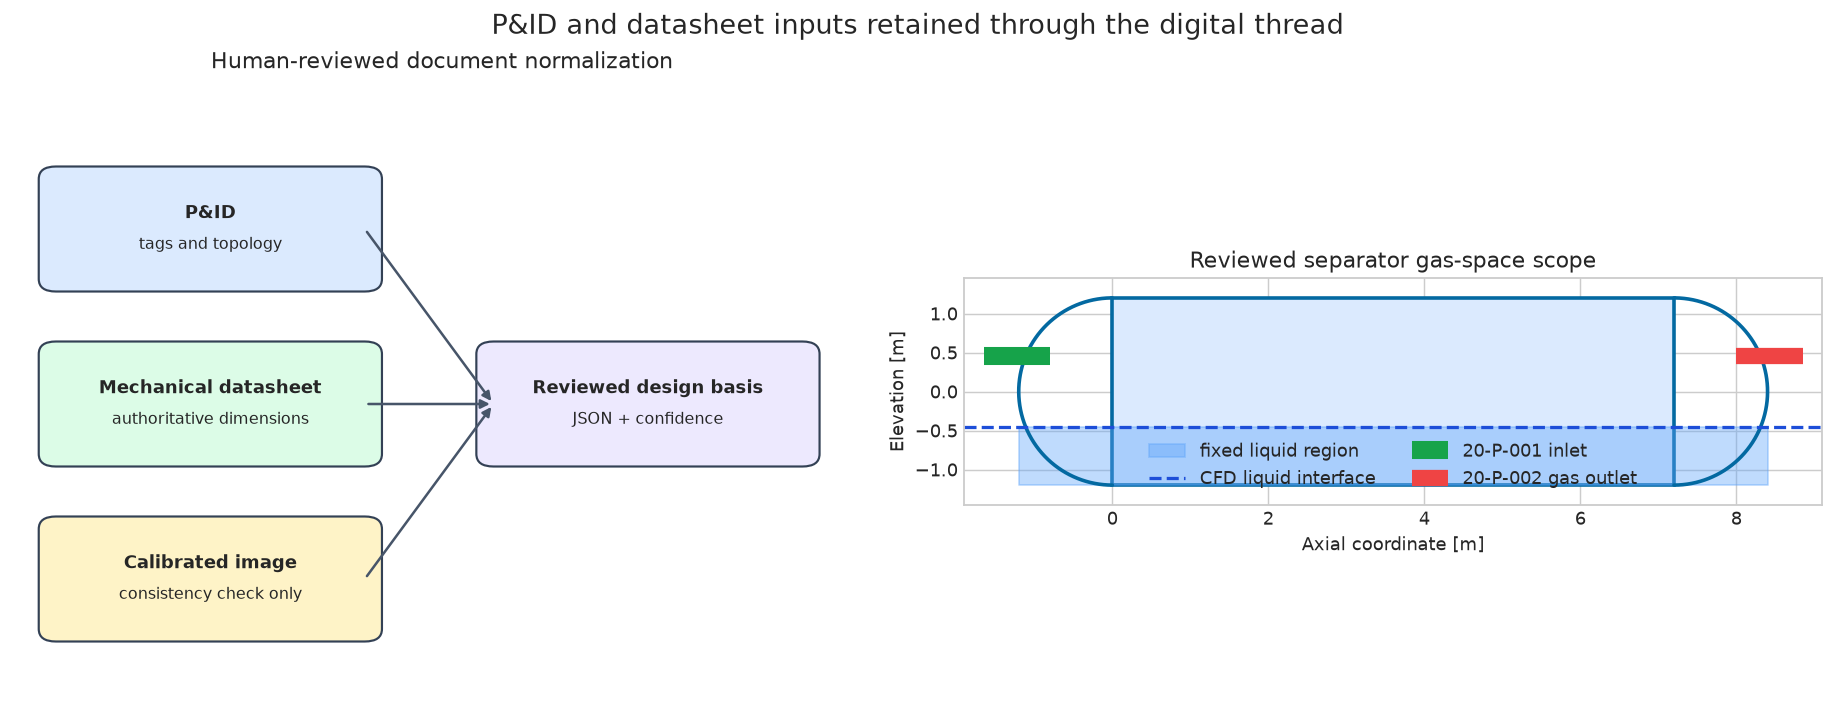

In [4]:
from matplotlib.patches import FancyBboxPatch
from matplotlib.patches import Rectangle


figure = plt.figure(
    figsize=(14, 5.4),
    constrained_layout=True,
)
trace_axis = figure.add_subplot(1, 2, 1)
schematic_axis = figure.add_subplot(1, 2, 2)

trace_axis.set_xlim(0.0, 1.0)
trace_axis.set_ylim(0.0, 1.0)
trace_axis.axis("off")
boxes = [
    (0.05, 0.68, "P&ID", "tags and topology", "#dbeafe"),
    (
        0.05,
        0.40,
        "Mechanical datasheet",
        "authoritative dimensions",
        "#dcfce7",
    ),
    (
        0.05,
        0.12,
        "Calibrated image",
        "consistency check only",
        "#fef3c7",
    ),
    (
        0.56,
        0.40,
        "Reviewed design basis",
        "JSON + confidence",
        "#ede9fe",
    ),
]
for x_pos, y_pos, title, subtitle, color in boxes:
    box = FancyBboxPatch(
        (x_pos, y_pos),
        0.36,
        0.16,
        boxstyle="round,pad=0.02",
        facecolor=color,
        edgecolor="#334155",
        linewidth=1.2,
    )
    trace_axis.add_patch(box)
    trace_axis.text(
        x_pos + 0.18,
        y_pos + 0.105,
        title,
        ha="center",
        va="center",
        weight="bold",
    )
    trace_axis.text(
        x_pos + 0.18,
        y_pos + 0.055,
        subtitle,
        ha="center",
        va="center",
        fontsize=9,
    )
for y_pos in (0.76, 0.48, 0.20):
    trace_axis.annotate(
        "",
        xy=(0.56, 0.48),
        xytext=(0.41, y_pos),
        arrowprops={
            "arrowstyle": "-|>",
            "color": "#475569",
            "linewidth": 1.4,
        },
    )
trace_axis.set_title("Human-reviewed document normalization")

diameter = mechanical["vessel_inside_diameter_m"]
length = mechanical["tangent_length_m"]
radius = 0.5 * diameter
liquid_z = (
    mechanical["liquid_level_from_bottom_m"]
    - radius
)
x_left = -radius
x_right = length + radius
body_rectangle = Rectangle(
    (0.0, -radius),
    length,
    diameter,
    facecolor="#dbeafe",
    edgecolor="#0369a1",
    linewidth=2.0,
)
schematic_axis.add_patch(body_rectangle)
theta = np.linspace(
    -0.5 * math.pi,
    0.5 * math.pi,
    200,
)
schematic_axis.plot(
    -radius * np.cos(theta),
    radius * np.sin(theta),
    color="#0369a1",
    linewidth=2.0,
)
schematic_axis.plot(
    length + radius * np.cos(theta),
    radius * np.sin(theta),
    color="#0369a1",
    linewidth=2.0,
)
schematic_axis.fill_between(
    [x_left, x_right],
    [-radius, -radius],
    [liquid_z, liquid_z],
    color="#60a5fa",
    alpha=0.40,
    label="fixed liquid region",
)
schematic_axis.axhline(
    liquid_z,
    color="#1d4ed8",
    linestyle="--",
    linewidth=1.8,
    label="CFD liquid interface",
)
nozzle_z = mechanical["nozzle_center_elevation_m"]
schematic_axis.plot(
    [
        mechanical["inlet_external_x_m"],
        -0.8,
    ],
    [nozzle_z, nozzle_z],
    color="#16a34a",
    linewidth=10.0,
    solid_capstyle="butt",
    label="20-P-001 inlet",
)
schematic_axis.plot(
    [
        8.0,
        mechanical["outlet_external_x_m"],
    ],
    [nozzle_z, nozzle_z],
    color="#ef4444",
    linewidth=9.0,
    solid_capstyle="butt",
    label="20-P-002 gas outlet",
)
schematic_axis.set_xlim(x_left - 0.7, x_right + 0.7)
schematic_axis.set_ylim(-radius - 0.25, radius + 0.25)
schematic_axis.set_aspect("equal", adjustable="box")
schematic_axis.set_xlabel("Axial coordinate [m]")
schematic_axis.set_ylabel("Elevation [m]")
schematic_axis.set_title("Reviewed separator gas-space scope")
schematic_axis.legend(loc="lower center", ncol=2)
figure.suptitle(
    "P&ID and datasheet inputs retained through the digital thread",
    fontsize=15,
)
plt.show()

## 5. Calculate the three-phase inlet with NeqSim

The synthetic feed uses the CPA model because water and hydrocarbon phase
behavior are relevant. The classic mixing-rule option is selected, multiphase
stability checking is enabled, and the P&ID inlet tag is retained on the
NeqSim stream.

In [5]:
from neqsim.thermo import TPflash
from neqsim.thermo import fluid


process_data = DOCUMENT_MODEL["process_datasheet"]
composition = process_data["composition_mole_fraction"]
composition_sum = sum(composition.values())
assert abs(composition_sum - 1.0) < 1.0e-12

separator_fluid = fluid("cpa")
for component_name, mole_fraction in composition.items():
    separator_fluid.addComponent(
        component_name,
        mole_fraction,
    )
separator_fluid.setMixingRule(10)
separator_fluid.setMultiPhaseCheck(True)
separator_fluid.setTemperature(
    process_data["temperature_c"],
    "C",
)
separator_fluid.setPressure(
    process_data["pressure_bara"],
    "bara",
)
separator_fluid.setTotalFlowRate(
    process_data["total_mass_flow_kg_per_h"],
    "kg/hr",
)
TPflash(separator_fluid)
separator_fluid.initProperties()

inlet_stream = jneqsim.process.equipment.stream.Stream(
    DOCUMENT_MODEL["pid"]["inlet_stream_tag"],
    separator_fluid,
)
inlet_stream.run()
stream_fluid = inlet_stream.getThermoSystem()

phase_rows = []
for phase_index in range(stream_fluid.getNumberOfPhases()):
    phase = stream_fluid.getPhase(phase_index)
    phase_rows.append(
        {
            "phase": str(phase.getPhaseTypeName()),
            "mass flow [kg/s]": phase.getFlowRate("kg/sec"),
            "actual flow [m3/s]": phase.getFlowRate("m3/sec"),
            "density [kg/m3]": phase.getDensity("kg/m3"),
            "viscosity [Pa s]": phase.getViscosity("kg/msec"),
        }
    )

phase_table = pd.DataFrame(phase_rows)
total_phase_mass_flow_kg_per_s = phase_table[
    "mass flow [kg/s]"
].sum()
specified_mass_flow_kg_per_s = (
    process_data["total_mass_flow_kg_per_h"] / 3_600.0
)
phase_mass_closure_relative = abs(
    total_phase_mass_flow_kg_per_s
    - specified_mass_flow_kg_per_s
) / specified_mass_flow_kg_per_s

assert stream_fluid.getNumberOfPhases() == 3
assert phase_mass_closure_relative < 1.0e-10
phase_table

,phase,mass flow [kg/s],actual flow [m3/s],density [kg/m3],viscosity [Pa s]
0,gas,22.4478,0.375891,59.7189,1.35574e-05
1,oil,10.3963,0.0185232,561.257,0.000154028
2,aqueous,0.489236,0.00049417,990.016,0.000596417


## 6. Translate the NeqSim gas phase into CFD inputs

The present CFD scope models only the gas space. The NeqSim gas phase supplies
the density, dynamic viscosity, actual volumetric flow, mass flow, and speed
of sound. Dynamic viscosity is converted to kinematic viscosity:

$$
\nu_g = \frac{\mu_g}{\rho_g}.
$$

The inlet velocity and Reynolds number are

$$
U_{\mathrm{in}} = \frac{Q_g}{A_{\mathrm{in}}},
\qquad
\mathrm{Re}_{\mathrm{in}}
= \frac{\rho_g U_{\mathrm{in}}D_{\mathrm{in}}}{\mu_g}.
$$

The Gmsh-triangulated inlet area is used later to preserve the exact NeqSim
volume flow on the discrete OpenFOAM boundary.

In [6]:
gas_phase = next(
    stream_fluid.getPhase(phase_index)
    for phase_index in range(
        stream_fluid.getNumberOfPhases()
    )
    if str(
        stream_fluid.getPhase(
            phase_index
        ).getPhaseTypeName()
    ).lower() == "gas"
)

gas_flow_m3_per_s = gas_phase.getFlowRate("m3/sec")
gas_mass_flow_kg_per_s = gas_phase.getFlowRate("kg/sec")
gas_density_kg_per_m3 = gas_phase.getDensity("kg/m3")
gas_viscosity_pa_s = gas_phase.getViscosity("kg/msec")
gas_sound_speed_m_per_s = gas_phase.getSoundSpeed()

GAS_FLOW_M3_PER_S = gas_flow_m3_per_s
GAS_DENSITY_KG_PER_M3 = gas_density_kg_per_m3
GAS_VISCOSITY_PA_S = gas_viscosity_pa_s
INLET_DIAMETER_M = (
    mechanical["inlet_nozzle_inside_diameter_m"]
)
OUTLET_DIAMETER_M = (
    mechanical["outlet_nozzle_inside_diameter_m"]
)
TURBULENCE_INTENSITY = 0.05
TURBULENCE_LENGTH_SCALE_M = 0.07 * INLET_DIAMETER_M
C_MU = 0.09

ideal_inlet_area_m2 = (
    math.pi * INLET_DIAMETER_M**2 / 4.0
)
ideal_inlet_velocity_m_per_s = (
    gas_flow_m3_per_s / ideal_inlet_area_m2
)
kinematic_viscosity_m2_per_s = (
    gas_viscosity_pa_s / gas_density_kg_per_m3
)
inlet_reynolds_number = (
    gas_density_kg_per_m3
    * ideal_inlet_velocity_m_per_s
    * INLET_DIAMETER_M
    / gas_viscosity_pa_s
)

assert gas_flow_m3_per_s > 0.0
assert inlet_reynolds_number > 4_000.0

coupling_table = pd.Series(
    {
        "gas actual flow [m3/s]": gas_flow_m3_per_s,
        "gas mass flow [kg/s]": gas_mass_flow_kg_per_s,
        "gas density [kg/m3]": gas_density_kg_per_m3,
        "gas dynamic viscosity [Pa s]": gas_viscosity_pa_s,
        "gas kinematic viscosity [m2/s]": (
            kinematic_viscosity_m2_per_s
        ),
        "ideal inlet velocity [m/s]": (
            ideal_inlet_velocity_m_per_s
        ),
        "inlet Reynolds number [-]": inlet_reynolds_number,
        "gas sound speed [m/s]": gas_sound_speed_m_per_s,
    },
    name="NeqSim gas-phase CFD boundary data",
)
coupling_table

gas actual flow [m3/s]              0.375891
gas mass flow [kg/s]                 22.4478
gas density [kg/m3]                  59.7189
gas dynamic viscosity [Pa s]     1.35574e-05
gas kinematic viscosity [m2/s]   2.27021e-07
ideal inlet velocity [m/s]            5.1516
inlet Reynolds number [-]        6.91659e+06
gas sound speed [m/s]                379.438
Name: NeqSim gas-phase CFD boundary data, dtype: float64

## 7. Generate the exact gas-space B-Rep with CadQuery

The CFD domain is the internal gas volume above the reviewed liquid level.
The cylinder, hemispherical heads, and axial nozzles are fused before the
fixed liquid region is removed. STEP is the geometry master. Separate STL
files are exported only for named-boundary exchange and visualization.

In [7]:
VESSEL_DIAMETER_M = mechanical["vessel_inside_diameter_m"]
VESSEL_RADIUS_M = 0.5 * VESSEL_DIAMETER_M
TANGENT_LENGTH_M = mechanical["tangent_length_m"]
LIQUID_LEVEL_Z_M = (
    mechanical["liquid_level_from_bottom_m"]
    - VESSEL_RADIUS_M
)
NOZZLE_CENTER_Z_M = mechanical[
    "nozzle_center_elevation_m"
]
X_MIN_M = mechanical["inlet_external_x_m"]
X_MAX_M = mechanical["outlet_external_x_m"]

cylindrical_body = (
    cq.Workplane("YZ")
    .circle(VESSEL_RADIUS_M)
    .extrude(TANGENT_LENGTH_M)
)
left_head = cq.Workplane(
    "YZ",
    origin=(0.0, 0.0, 0.0),
).sphere(VESSEL_RADIUS_M)
right_head = cq.Workplane(
    "YZ",
    origin=(TANGENT_LENGTH_M, 0.0, 0.0),
).sphere(VESSEL_RADIUS_M)

inlet_nozzle = (
    cq.Workplane(
        "YZ",
        origin=(X_MIN_M, 0.0, NOZZLE_CENTER_Z_M),
    )
    .circle(0.5 * INLET_DIAMETER_M)
    .extrude(
        mechanical["inlet_internal_x_m"] - X_MIN_M
    )
)
outlet_nozzle = (
    cq.Workplane(
        "YZ",
        origin=(
            mechanical["outlet_internal_x_m"],
            0.0,
            NOZZLE_CENTER_Z_M,
        ),
    )
    .circle(0.5 * OUTLET_DIAMETER_M)
    .extrude(
        X_MAX_M - mechanical["outlet_internal_x_m"]
    )
)

full_internal_volume = (
    cylindrical_body
    .union(left_head)
    .union(right_head)
    .union(inlet_nozzle)
    .union(outlet_nozzle)
)
gas_clip = (
    cq.Workplane(
        "XY",
        origin=(
            X_MIN_M - 0.5,
            -2.0,
            LIQUID_LEVEL_Z_M,
        ),
    )
    .box(
        X_MAX_M - X_MIN_M + 1.0,
        4.0,
        3.0,
        centered=(False, False, False),
    )
)
gas_domain = full_internal_volume.intersect(gas_clip)
fluid_shape = gas_domain.val()

assert fluid_shape.isValid()
assert len(fluid_shape.Solids()) == 1

STEP_PATH = GEOMETRY_DIR / "20-VG-001_gas_space.step"
cq.exporters.export(
    fluid_shape,
    str(STEP_PATH),
)

inlet_faces = []
outlet_faces = []
interface_faces = []
wall_faces = []
for face in fluid_shape.Faces():
    bounds = face.BoundingBox()
    if (
        abs(bounds.xmin - X_MIN_M) < 1.0e-6
        and abs(bounds.xmax - X_MIN_M) < 1.0e-6
    ):
        inlet_faces.append(face)
    elif (
        abs(bounds.xmin - X_MAX_M) < 1.0e-6
        and abs(bounds.xmax - X_MAX_M) < 1.0e-6
    ):
        outlet_faces.append(face)
    elif (
        abs(bounds.zmin - LIQUID_LEVEL_Z_M) < 1.0e-6
        and abs(bounds.zmax - LIQUID_LEVEL_Z_M) < 1.0e-6
    ):
        interface_faces.append(face)
    else:
        wall_faces.append(face)

named_faces = {
    "inlet": inlet_faces,
    "outlet": outlet_faces,
    "liquidInterface": interface_faces,
    "walls": wall_faces,
}
for boundary_name, faces in named_faces.items():
    if not faces:
        raise RuntimeError(
            f"No CAD faces found for {boundary_name}"
        )
    boundary_shape = cq.Compound.makeCompound(faces)
    cq.exporters.export(
        boundary_shape,
        str(GEOMETRY_DIR / f"{boundary_name}.stl"),
        tolerance=0.02,
    )

cad_volume_m3 = fluid_shape.Volume()
cad_summary = pd.Series(
    {
        "valid solids [-]": len(fluid_shape.Solids()),
        "CAD faces [-]": len(fluid_shape.Faces()),
        "gas-space volume [m3]": cad_volume_m3,
        "STEP size [kB]": STEP_PATH.stat().st_size / 1_024.0,
        "named boundaries [-]": len(named_faces),
        "liquid-interface elevation [m]": LIQUID_LEVEL_Z_M,
    },
    name="CadQuery gas-space model",
)
cad_summary

valid solids [-]                       1
CAD faces [-]                          8
gas-space volume [m3]            29.5022
STEP size [kB]                   53.3037
named boundaries [-]                   4
liquid-interface elevation [m]     -0.45
Name: CadQuery gas-space model, dtype: float64

## 8. Inspect the CAD and named boundaries

The three-dimensional rendering is generated from the actual CadQuery shape.
The longitudinal schematic shows the fixed interface and the two document-
defined nozzles.

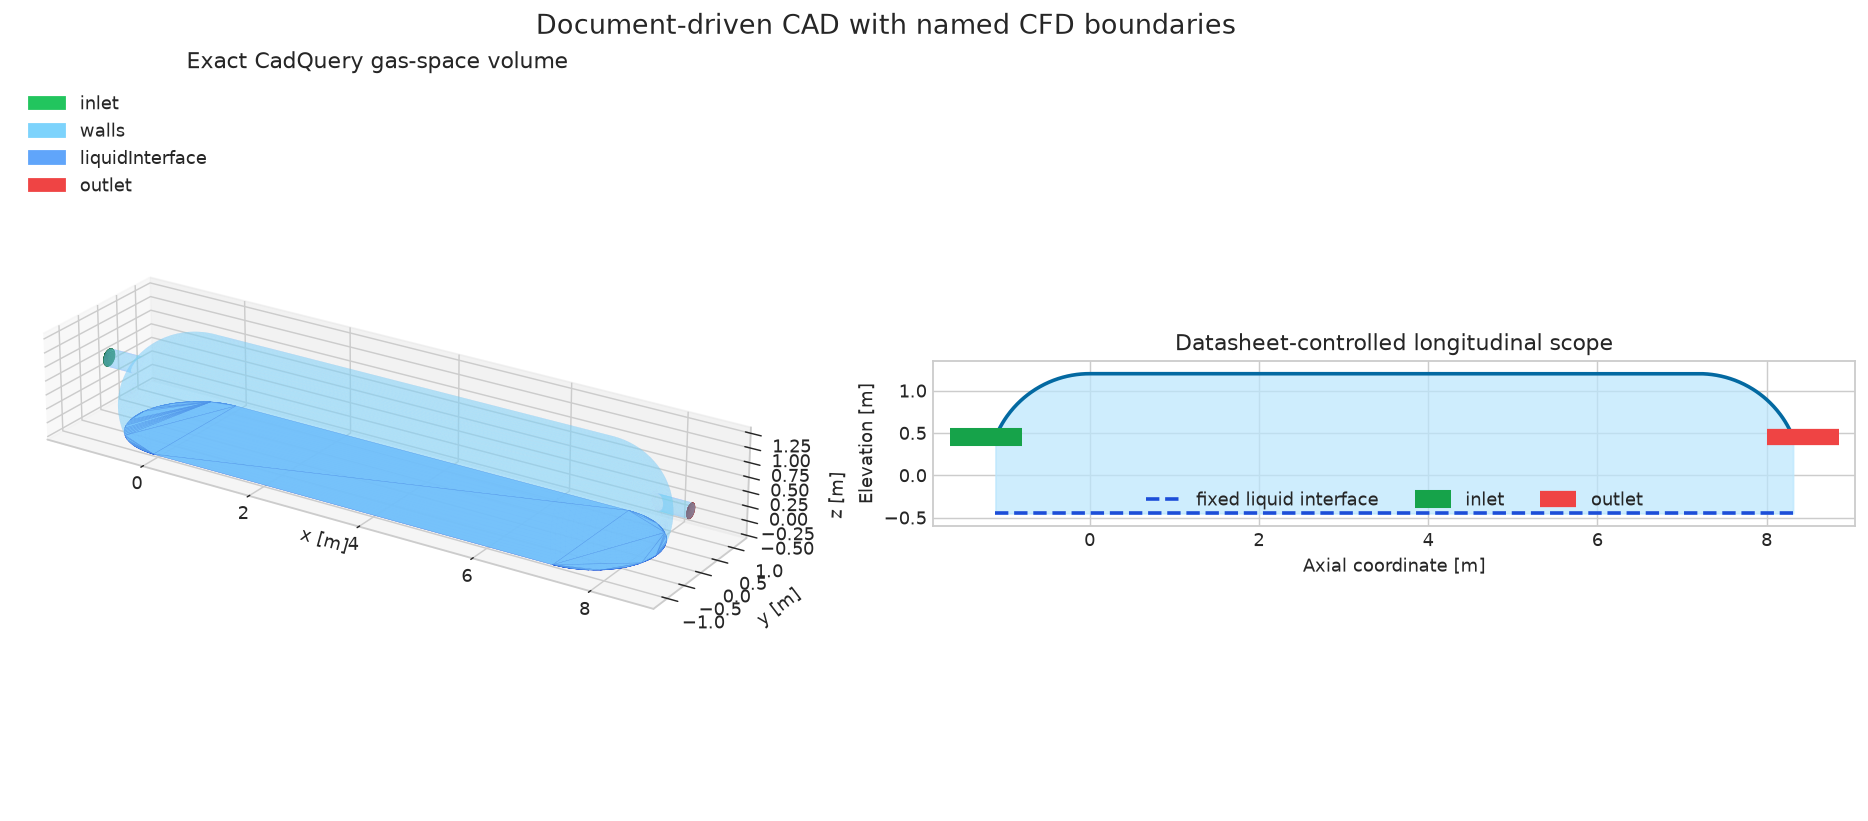

In [8]:
def tessellated_triangles(shape, tolerance=0.05):
    vertices, triangles = shape.tessellate(tolerance)
    points = np.array(
        [
            [vertex.x, vertex.y, vertex.z]
            for vertex in vertices
        ]
    )
    return points[np.asarray(triangles)]


domain_triangles = tessellated_triangles(fluid_shape)
inlet_triangles = tessellated_triangles(
    cq.Compound.makeCompound(inlet_faces)
)
outlet_triangles = tessellated_triangles(
    cq.Compound.makeCompound(outlet_faces)
)
interface_triangles = tessellated_triangles(
    cq.Compound.makeCompound(interface_faces)
)

figure = plt.figure(
    figsize=(15, 6.2),
    constrained_layout=True,
)
cad_axis = figure.add_subplot(1, 2, 1, projection="3d")
cad_axis.add_collection3d(
    Poly3DCollection(
        domain_triangles,
        facecolor="#7dd3fc",
        edgecolor="none",
        alpha=0.35,
    )
)
for triangles, face_color, edge_color in (
    (inlet_triangles, "#22c55e", "#166534"),
    (outlet_triangles, "#ef4444", "#991b1b"),
    (interface_triangles, "#60a5fa", "#1d4ed8"),
):
    cad_axis.add_collection3d(
        Poly3DCollection(
            triangles,
            facecolor=face_color,
            edgecolor=edge_color,
            linewidth=0.20,
            alpha=0.90,
        )
    )
cad_axis.set_xlim(X_MIN_M - 0.2, X_MAX_M + 0.2)
cad_axis.set_ylim(-1.4, 1.4)
cad_axis.set_zlim(LIQUID_LEVEL_Z_M - 0.1, 1.35)
cad_axis.set_box_aspect((10.9, 2.8, 1.8))
cad_axis.set_xlabel("x [m]")
cad_axis.set_ylabel("y [m]")
cad_axis.set_zlabel("z [m]")
cad_axis.view_init(elev=24, azim=-57)
cad_axis.set_title("Exact CadQuery gas-space volume")
cad_axis.legend(
    handles=[
        Patch(color="#22c55e", label="inlet"),
        Patch(color="#7dd3fc", label="walls"),
        Patch(color="#60a5fa", label="liquidInterface"),
        Patch(color="#ef4444", label="outlet"),
    ],
    loc="upper left",
)

profile_axis = figure.add_subplot(1, 2, 2)
x_main_left = -math.sqrt(
    VESSEL_RADIUS_M**2 - LIQUID_LEVEL_Z_M**2
)
x_main_right = TANGENT_LENGTH_M - x_main_left
x_profile = np.linspace(
    x_main_left,
    x_main_right,
    700,
)
top_profile = np.full_like(
    x_profile,
    VESSEL_RADIUS_M,
)
left_mask = x_profile < 0.0
right_mask = x_profile > TANGENT_LENGTH_M
top_profile[left_mask] = np.sqrt(
    VESSEL_RADIUS_M**2 - x_profile[left_mask] ** 2
)
top_profile[right_mask] = np.sqrt(
    VESSEL_RADIUS_M**2
    - (
        x_profile[right_mask] - TANGENT_LENGTH_M
    )
    ** 2
)
profile_axis.fill_between(
    x_profile,
    LIQUID_LEVEL_Z_M,
    top_profile,
    color="#bae6fd",
    alpha=0.70,
)
profile_axis.plot(
    x_profile,
    top_profile,
    color="#0369a1",
    linewidth=2.0,
)
profile_axis.plot(
    [x_main_left, x_main_right],
    [LIQUID_LEVEL_Z_M, LIQUID_LEVEL_Z_M],
    color="#1d4ed8",
    linestyle="--",
    linewidth=2.0,
    label="fixed liquid interface",
)
profile_axis.plot(
    [X_MIN_M, -0.8],
    [NOZZLE_CENTER_Z_M, NOZZLE_CENTER_Z_M],
    color="#16a34a",
    linewidth=10.0,
    solid_capstyle="butt",
    label="inlet",
)
profile_axis.plot(
    [8.0, X_MAX_M],
    [NOZZLE_CENTER_Z_M, NOZZLE_CENTER_Z_M],
    color="#ef4444",
    linewidth=9.0,
    solid_capstyle="butt",
    label="outlet",
)
profile_axis.set_xlim(X_MIN_M - 0.2, X_MAX_M + 0.2)
profile_axis.set_ylim(LIQUID_LEVEL_Z_M - 0.15, 1.35)
profile_axis.set_aspect("equal", adjustable="box")
profile_axis.set_xlabel("Axial coordinate [m]")
profile_axis.set_ylabel("Elevation [m]")
profile_axis.set_title("Datasheet-controlled longitudinal scope")
profile_axis.legend(loc="lower center", ncol=3)
figure.suptitle(
    "Document-driven CAD with named CFD boundaries",
    fontsize=15,
)
plt.show()

## 9. Import STEP and generate the named Gmsh mesh

Gmsh imports the STEP master through OpenCascade. Bounding-box checks classify
the inlet, outlet, fixed liquid interface, and vessel walls. The mesh is
locally refined through both nozzles and along the gas-jet path.

In [9]:
MSH_PATH = GEOMETRY_DIR / "20-VG-001_gas_space.msh"


def triangulated_surface_area(surface_tag_list):
    area_m2 = 0.0
    for surface_tag in surface_tag_list:
        element_types, _, element_node_lists = (
            gmsh.model.mesh.getElements(2, surface_tag)
        )
        for element_type, element_node_list in zip(
            element_types,
            element_node_lists,
        ):
            properties = gmsh.model.mesh.getElementProperties(
                element_type
            )
            number_of_nodes = properties[3]
            number_of_primary_nodes = properties[5]
            if number_of_primary_nodes != 3:
                raise RuntimeError(
                    "Expected triangular surface elements"
                )
            connectivity = np.asarray(
                element_node_list,
                dtype=int,
            ).reshape(-1, number_of_nodes)
            for element_nodes in connectivity:
                points = np.vstack(
                    [
                        gmsh.model.mesh.getNode(
                            int(node_tag)
                        )[0]
                        for node_tag in element_nodes[:3]
                    ]
                )
                area_m2 += 0.5 * np.linalg.norm(
                    np.cross(
                        points[1] - points[0],
                        points[2] - points[0],
                    )
                )
    return area_m2


gmsh.initialize()
try:
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.model.add("20_VG_001_gas_space")
    gmsh.model.occ.importShapes(str(STEP_PATH))
    gmsh.model.occ.synchronize()

    volume_tags = [
        tag
        for dimension, tag in gmsh.model.getEntities(3)
    ]
    if len(volume_tags) != 1:
        raise RuntimeError("Expected exactly one gas volume")

    gmsh_volume_m3 = gmsh.model.occ.getMass(
        3,
        volume_tags[0],
    )
    cad_gmsh_volume_error_relative = abs(
        gmsh_volume_m3 - cad_volume_m3
    ) / cad_volume_m3

    boundary_entities = gmsh.model.getBoundary(
        [(3, volume_tags[0])],
        oriented=False,
    )
    surface_tags = [
        tag
        for dimension, tag in boundary_entities
        if dimension == 2
    ]
    inlet_tags = []
    outlet_tags = []
    interface_tags = []
    wall_tags = []
    for surface_tag in surface_tags:
        bounds = gmsh.model.getBoundingBox(
            2,
            surface_tag,
        )
        if (
            abs(bounds[0] - X_MIN_M) < 1.0e-5
            and abs(bounds[3] - X_MIN_M) < 1.0e-5
        ):
            inlet_tags.append(surface_tag)
        elif (
            abs(bounds[0] - X_MAX_M) < 1.0e-5
            and abs(bounds[3] - X_MAX_M) < 1.0e-5
        ):
            outlet_tags.append(surface_tag)
        elif (
            abs(bounds[2] - LIQUID_LEVEL_Z_M) < 1.0e-5
            and abs(bounds[5] - LIQUID_LEVEL_Z_M) < 1.0e-5
        ):
            interface_tags.append(surface_tag)
        else:
            wall_tags.append(surface_tag)

    physical_groups = {
        "fluid": (3, volume_tags),
        "inlet": (2, inlet_tags),
        "outlet": (2, outlet_tags),
        "liquidInterface": (2, interface_tags),
        "walls": (2, wall_tags),
    }
    for group_name, group_data in physical_groups.items():
        dimension, tags = group_data
        group_tag = gmsh.model.addPhysicalGroup(
            dimension,
            tags,
        )
        gmsh.model.setPhysicalName(
            dimension,
            group_tag,
            group_name,
        )

    gmsh.option.setNumber("Mesh.MeshSizeMin", 0.055)
    gmsh.option.setNumber("Mesh.MeshSizeMax", 0.32)
    refinement_fields = []
    for x_min, x_max in (
        (X_MIN_M - 0.25, 0.20),
        (7.00, X_MAX_M + 0.25),
    ):
        field = gmsh.model.mesh.field.add("Box")
        refinement_fields.append(field)
        gmsh.model.mesh.field.setNumber(field, "VIn", 0.065)
        gmsh.model.mesh.field.setNumber(field, "VOut", 0.28)
        for key, value in {
            "XMin": x_min,
            "XMax": x_max,
            "YMin": -0.40,
            "YMax": 0.40,
            "ZMin": 0.10,
            "ZMax": 0.80,
        }.items():
            gmsh.model.mesh.field.setNumber(
                field,
                key,
                value,
            )

    jet_field = gmsh.model.mesh.field.add("Box")
    refinement_fields.append(jet_field)
    gmsh.model.mesh.field.setNumber(
        jet_field,
        "VIn",
        0.16,
    )
    gmsh.model.mesh.field.setNumber(
        jet_field,
        "VOut",
        0.28,
    )
    for key, value in {
        "XMin": -0.80,
        "XMax": 8.00,
        "YMin": -0.80,
        "YMax": 0.80,
        "ZMin": -0.30,
        "ZMax": 1.00,
    }.items():
        gmsh.model.mesh.field.setNumber(
            jet_field,
            key,
            value,
        )

    minimum_field = gmsh.model.mesh.field.add("Min")
    gmsh.model.mesh.field.setNumbers(
        minimum_field,
        "FieldsList",
        refinement_fields,
    )
    gmsh.model.mesh.field.setAsBackgroundMesh(
        minimum_field
    )

    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
    gmsh.option.setNumber("Mesh.Binary", 0)
    gmsh.model.mesh.generate(3)
    mesh_inlet_area_m2 = triangulated_surface_area(
        inlet_tags
    )
    mesh_outlet_area_m2 = triangulated_surface_area(
        outlet_tags
    )
    gmsh.write(str(MSH_PATH))

    node_tags, _, _ = gmsh.model.mesh.getNodes()
    _, tetrahedron_tags, _ = gmsh.model.mesh.getElements(3)
    mesh_node_count = len(node_tags)
    mesh_cell_count = sum(
        len(tags)
        for tags in tetrahedron_tags
    )
finally:
    gmsh.finalize()

assert inlet_tags
assert outlet_tags
assert interface_tags
assert wall_tags
assert mesh_cell_count > 20_000
assert cad_gmsh_volume_error_relative < 1.0e-8

mesh_summary = pd.Series(
    {
        "nodes [-]": mesh_node_count,
        "tetrahedra [-]": mesh_cell_count,
        "CAD-Gmsh STEP volume error [-]": (
            cad_gmsh_volume_error_relative
        ),
        "triangulated inlet area [m2]": mesh_inlet_area_m2,
        "triangulated outlet area [m2]": mesh_outlet_area_m2,
        "physical groups [-]": len(physical_groups),
        "MSH size [MB]": MSH_PATH.stat().st_size / 1.0e6,
    },
    name="Gmsh named volume mesh",
)
mesh_summary

nodes [-]                             8,750
tetrahedra [-]                       47,630
CAD-Gmsh STEP volume error [-]   4.0964e-10
triangulated inlet area [m2]      0.0708508
triangulated outlet area [m2]     0.0487209
physical groups [-]                       5
MSH size [MB]                       2.24164
Name: Gmsh named volume mesh, dtype: float64

## 10. Inspect the actual tetrahedral mesh

The cut plane passes through both nozzles and the vessel axis. Cell size
decreases around the inlet/outlet and along the jet path. A production model
would normally add wall-normal prism layers and complete mesh-independence
and near-wall-resolution studies.

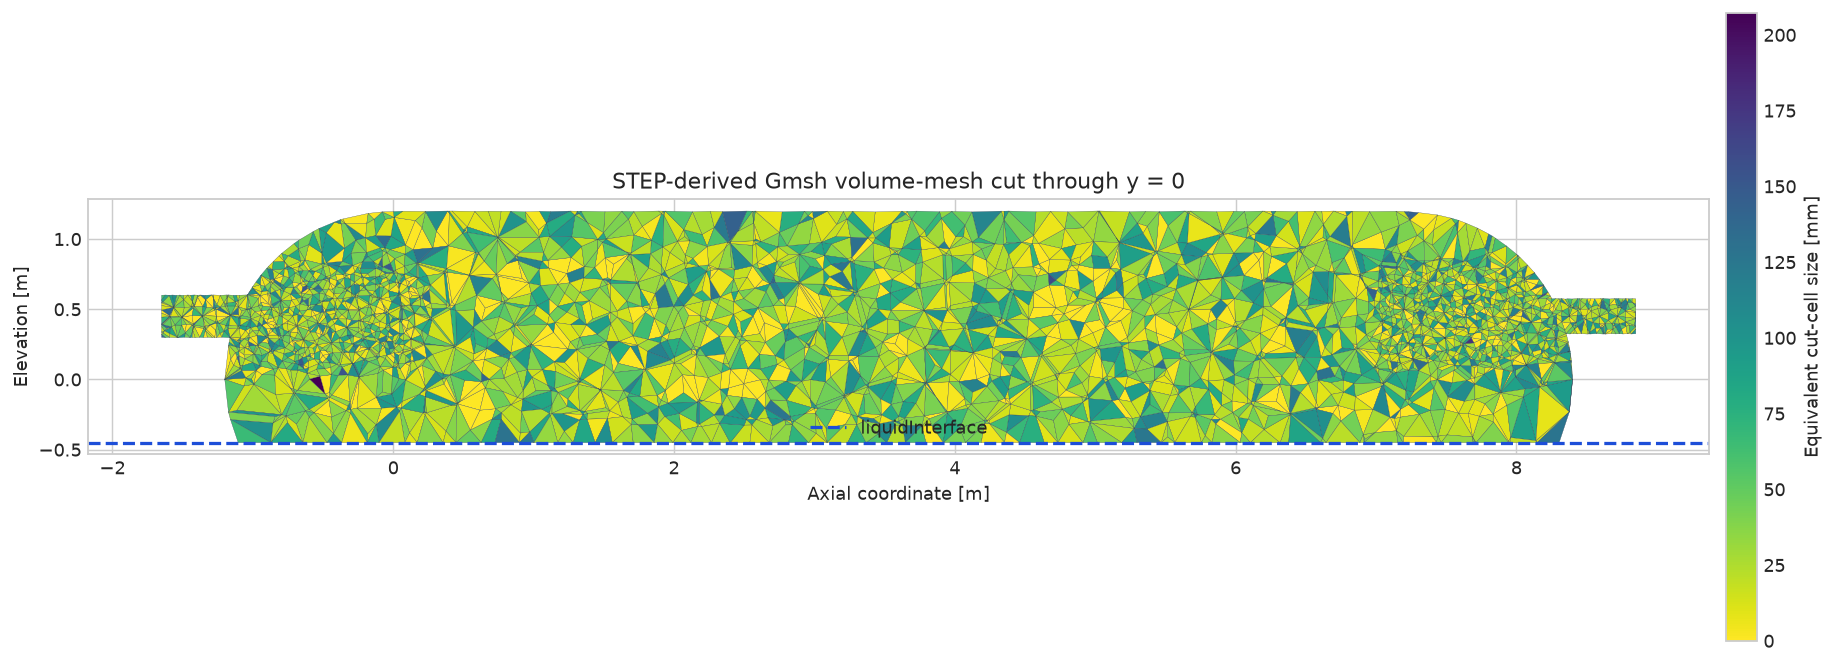

In [10]:
gmsh_mesh = pv.read(MSH_PATH)
mesh_slice = gmsh_mesh.slice(
    normal=(0.0, 1.0, 0.0),
)
slice_sizes = mesh_slice.compute_cell_sizes(
    length=False,
    area=True,
    volume=False,
)

faces = mesh_slice.faces
polygons = []
cursor = 0
while cursor < len(faces):
    vertex_count = int(faces[cursor])
    indices = faces[
        cursor + 1 : cursor + 1 + vertex_count
    ]
    polygons.append(
        mesh_slice.points[indices][:, [0, 2]]
    )
    cursor += vertex_count + 1

equivalent_size_mm = (
    1_000.0
    * np.sqrt(slice_sizes.cell_data["Area"])
)
collection = PolyCollection(
    polygons,
    array=equivalent_size_mm,
    cmap="viridis_r",
    edgecolor="#334155",
    linewidth=0.16,
)

figure, mesh_axis = plt.subplots(
    figsize=(14, 5.0),
    constrained_layout=True,
)
mesh_axis.add_collection(collection)
mesh_axis.autoscale_view()
mesh_axis.axhline(
    LIQUID_LEVEL_Z_M,
    color="#1d4ed8",
    linestyle="--",
    linewidth=1.8,
    label="liquidInterface",
)
mesh_axis.set_aspect("equal", adjustable="box")
mesh_axis.set_xlabel("Axial coordinate [m]")
mesh_axis.set_ylabel("Elevation [m]")
mesh_axis.set_title(
    "STEP-derived Gmsh volume-mesh cut through y = 0"
)
mesh_axis.legend(loc="lower center")
figure.colorbar(
    collection,
    ax=mesh_axis,
    label="Equivalent cut-cell size [mm]",
    pad=0.01,
)
plt.show()

## 11. OpenFOAM environment and execution helpers

The environment is assembled explicitly instead of sourcing an interactive
shell. Patch types are corrected after `gmshToFoam`: vessel surfaces become
`wall` and the fixed liquid plane becomes `symmetryPlane`.

In [11]:
def foam_environment():
    library_root = (
        OPENFOAM_ROOT
        / "platforms"
        / OPENFOAM_PLATFORM
        / "lib"
    )
    binary_root = (
        OPENFOAM_ROOT
        / "platforms"
        / OPENFOAM_PLATFORM
        / "bin"
    )
    environment = os.environ.copy()
    environment.update(
        {
            "WM_PROJECT_DIR": str(OPENFOAM_ROOT),
            "WM_PROJECT_VERSION": "14",
            "WM_PROJECT": "OpenFOAM",
            "FOAM_ETC": str(OPENFOAM_ROOT / "etc"),
            "FOAM_APPBIN": str(binary_root),
            "FOAM_LIBBIN": str(library_root),
            "FOAM_TUTORIALS": str(
                OPENFOAM_ROOT / "tutorials"
            ),
            "PATH": (
                f"{binary_root}:"
                f"{OPENFOAM_ROOT / 'bin'}:"
                f"{environment['PATH']}"
            ),
            "LD_LIBRARY_PATH": (
                f"{library_root / 'dummy'}:"
                f"{library_root}:"
                f"{environment.get('LD_LIBRARY_PATH', '')}"
            ),
        }
    )
    return environment


def run_foam(command, timeout_seconds=1_800):
    working_directory = (
        CASE_DIR
        if CASE_DIR.is_dir()
        else RUNTIME_DIR
    )
    result = subprocess.run(
        command,
        cwd=working_directory,
        env=foam_environment(),
        check=False,
        text=True,
        capture_output=True,
        timeout=timeout_seconds,
    )
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError(
            "OpenFOAM command failed: "
            + " ".join(command)
        )
    return result


def replace_patch_types():
    boundary_path = (
        CASE_DIR
        / "constant"
        / "polyMesh"
        / "boundary"
    )
    source = boundary_path.read_text()
    patch_types = {
        "walls": "wall",
        "liquidInterface": "symmetryPlane",
    }
    for patch_name, patch_type in patch_types.items():
        pattern = (
            rf"({patch_name}\s*\{{.*?\btype\s+)"
            r"patch(\s*;)"
        )
        source, replacement_count = re.subn(
            pattern,
            rf"\g<1>{patch_type}\g<2>",
            source,
            flags=re.DOTALL,
        )
        if replacement_count != 1:
            raise RuntimeError(
                f"Could not identify the {patch_name} patch"
            )
    boundary_path.write_text(source)


foam_version = run_foam(
    ["foamRun", "-help"],
).stdout.splitlines()[-2]
print(foam_version)

Build: 14-7b05503f98a8


## 12. Create the transparent OpenFOAM case

The case uses the steady incompressible OpenFOAM 14 solver with a standard
k-epsilon RANS closure. NeqSim supplies gas density and viscosity; the
triangulated inlet area preserves the NeqSim gas volume flow.

The fixed liquid plane is a symmetry boundary, so this screen does not model
waves, entrainment, droplets, coalescence, or liquid-interface shear.

In [12]:
def write_case_files(inlet_area_m2):
    velocity = GAS_FLOW_M3_PER_S / inlet_area_m2
    k_value = 1.5 * (TURBULENCE_INTENSITY * velocity) ** 2
    epsilon_value = (
        C_MU**0.75
        * k_value**1.5
        / TURBULENCE_LENGTH_SCALE_M
    )
    nu = GAS_VISCOSITY_PA_S / GAS_DENSITY_KG_PER_M3

    zero_dir = CASE_DIR / "0"
    system_dir = CASE_DIR / "system"
    constant_dir = CASE_DIR / "constant"
    for directory in (zero_dir, system_dir, constant_dir):
        directory.mkdir(parents=True, exist_ok=True)

    template = (
        OPENFOAM_ROOT
        / "tutorials"
        / "incompressibleFluid"
        / "pitzDailySteady"
    )
    for name in ("controlDict", "fvSchemes", "fvSolution"):
        shutil.copy(template / "system" / name, system_dir / name)
    for name in ("physicalProperties", "momentumTransport"):
        shutil.copy(template / "constant" / name, constant_dir / name)

    physical_path = constant_dir / "physicalProperties"
    physical = physical_path.read_text()
    physical = re.sub(
        r"(?m)^nu\s+[^;]+;",
        f"nu              {nu:.10g};",
        physical,
    )
    physical_path.write_text(physical)

    control_path = system_dir / "controlDict"
    control = control_path.read_text()
    control = re.sub(
        r"(?m)^endTime\s+[^;]+;",
        "endTime         1800;",
        control,
    )
    control = re.sub(
        r"(?m)^writeInterval\s+[^;]+;",
        "writeInterval   600;",
        control,
    )
    control_path.write_text(control)

    solution_path = system_dir / "fvSolution"
    solution = solution_path.read_text()
    solution = solution.replace(
        "solvers\n{",
        """solvers
{
    Phi
    {
        solver          GAMG;
        smoother        DIC;
        tolerance       1e-06;
        relTol          0.01;
    }
""",
        1,
    )
    solution = solution.replace(
        "SIMPLE\n{",
        """potentialFlow
{
    nNonOrthogonalCorrectors 2;
}

SIMPLE
{""",
        1,
    )
    solution = solution.replace(
        "nNonOrthogonalCorrectors 0;",
        "nNonOrthogonalCorrectors 2;",
    )
    solution = solution.replace(
        "relTol          0.1;",
        "relTol          0.05;",
    )
    solution = solution.replace(
        "U               1e-3;",
        "U               5e-3;",
    )
    solution = solution.replace(
        '"(k|epsilon|omega|f|v2)" 1e-3;',
        '"(k|epsilon|omega|f|v2)" 6e-3;',
    )
    solution = solution.replace(
        "U               0.9;",
        "U               0.65;",
    )
    solution = solution.replace(
        '".*"            0.9;',
        '".*"            0.65;',
    )
    solution_path.write_text(solution)

    fields = {
        "U": f"""FoamFile
{{
    format ascii;
    class volVectorField;
    location "0";
    object U;
}}
dimensions [velocity];
internalField uniform ({velocity:.10g} 0 0);
boundaryField
{{
    inlet
    {{
        type fixedValue;
        value uniform ({velocity:.10g} 0 0);
    }}
    outlet
    {{
        type zeroGradient;
    }}
    walls
    {{
        type noSlip;
    }}
    liquidInterface
    {{
        type symmetryPlane;
    }}
}}
""",
        "p": """FoamFile
{
    format ascii;
    class volScalarField;
    location "0";
    object p;
}
dimensions [kinematicPressure];
internalField uniform 0;
boundaryField
{
    inlet
    {
        type zeroGradient;
    }
    outlet
    {
        type fixedValue;
        value uniform 0;
    }
    walls
    {
        type zeroGradient;
    }
    liquidInterface
    {
        type symmetryPlane;
    }
}
""",
        "k": f"""FoamFile
{{
    format ascii;
    class volScalarField;
    location "0";
    object k;
}}
dimensions [turbulentKineticEnergy];
internalField uniform {k_value:.10g};
boundaryField
{{
    inlet
    {{
        type fixedValue;
        value uniform {k_value:.10g};
    }}
    outlet
    {{
        type inletOutlet;
        inletValue uniform {k_value:.10g};
        value uniform {k_value:.10g};
    }}
    walls
    {{
        type kqRWallFunction;
        value uniform {k_value:.10g};
    }}
    liquidInterface
    {{
        type symmetryPlane;
    }}
}}
""",
        "epsilon": f"""FoamFile
{{
    format ascii;
    class volScalarField;
    location "0";
    object epsilon;
}}
dimensions [turbulentEpsilon];
internalField uniform {epsilon_value:.10g};
boundaryField
{{
    inlet
    {{
        type fixedValue;
        value uniform {epsilon_value:.10g};
    }}
    outlet
    {{
        type inletOutlet;
        inletValue uniform {epsilon_value:.10g};
        value uniform {epsilon_value:.10g};
    }}
    walls
    {{
        type epsilonWallFunction;
        value uniform {epsilon_value:.10g};
    }}
    liquidInterface
    {{
        type symmetryPlane;
    }}
}}
""",
        "nut": """FoamFile
{
    format ascii;
    class volScalarField;
    location "0";
    object nut;
}
dimensions [kinematicViscosity];
internalField uniform 0;
boundaryField
{
    inlet
    {
        type calculated;
        value uniform 0;
    }
    outlet
    {
        type calculated;
        value uniform 0;
    }
    walls
    {
        type nutkWallFunction;
        value uniform 0;
    }
    liquidInterface
    {
        type symmetryPlane;
    }
}
""",
    }
    for name, source in fields.items():
        (zero_dir / name).write_text(source)
    return velocity, k_value, epsilon_value

## 13. Convert, check, initialize, and solve

The named Gmsh patches are converted directly to OpenFOAM. `checkMesh`
provides the topology and geometry gate, potential flow initializes the jet,
and the steady RANS solver must report residual convergence.

In [13]:
CASE_DIR.mkdir(parents=True)
boundary_inputs = write_case_files(
    mesh_inlet_area_m2
)

conversion_result = run_foam(
    [
        "gmshToFoam",
        str(MSH_PATH),
        "-case",
        str(CASE_DIR),
    ]
)
(CASE_DIR / "log.gmshToFoam").write_text(
    conversion_result.stdout
)
replace_patch_types()

mesh_check = run_foam(
    [
        "checkMesh",
        "-case",
        str(CASE_DIR),
    ]
)
(CASE_DIR / "log.checkMesh").write_text(
    mesh_check.stdout
)
if "Mesh OK." not in mesh_check.stdout:
    raise RuntimeError("OpenFOAM mesh check did not pass")

potential_result = run_foam(
    [
        "potentialFoam",
        "-case",
        str(CASE_DIR),
        "-initialiseUBCs",
    ]
)
(CASE_DIR / "log.potentialFoam").write_text(
    potential_result.stdout
)

solver_result = run_foam(
    [
        "foamRun",
        "-case",
        str(CASE_DIR),
        "-solver",
        "incompressibleFluid",
    ],
    timeout_seconds=1_800,
)
(CASE_DIR / "log.foamRun").write_text(
    solver_result.stdout
)

convergence_match = re.search(
    r"SIMPLE solution converged in\s+(\d+) iterations",
    solver_result.stdout,
)
if convergence_match is None:
    raise RuntimeError(
        "The steady OpenFOAM solution did not converge"
    )
solver_iterations = int(convergence_match.group(1))

vtk_result = run_foam(
    [
        "foamToVTK",
        "-case",
        str(CASE_DIR),
        "-latestTime",
    ]
)
(CASE_DIR / "log.foamToVTK").write_text(
    vtk_result.stdout
)
latest_time = run_foam(
    [
        "foamListTimes",
        "-case",
        str(CASE_DIR),
        "-latestTime",
    ]
).stdout.strip()


def extract_check_value(pattern, text):
    match = re.search(pattern, text)
    if match is None:
        raise RuntimeError(
            f"Mesh-check value not found: {pattern}"
        )
    return float(match.group(1))


check_table = pd.Series(
    {
        "OpenFOAM cells [-]": extract_check_value(
            r"cells:\s+(\d+)",
            mesh_check.stdout,
        ),
        "maximum aspect ratio [-]": extract_check_value(
            r"Max aspect ratio =\s*([0-9.eE+-]+)",
            mesh_check.stdout,
        ),
        "maximum non-orthogonality [deg]": (
            extract_check_value(
                r"Mesh non-orthogonality Max:\s*"
                r"([0-9.eE+-]+)",
                mesh_check.stdout,
            )
        ),
        "maximum skewness [-]": extract_check_value(
            r"Max skewness =\s*([0-9.eE+-]+)",
            mesh_check.stdout,
        ),
        "solver iterations [-]": solver_iterations,
        "latest time index [-]": float(latest_time),
        "mesh check passed": True,
        "steady convergence reported": True,
    },
    name="OpenFOAM execution",
)
check_table

OpenFOAM cells [-]                  47,630
maximum aspect ratio [-]           7.99208
maximum non-orthogonality [deg]    65.0238
maximum skewness [-]              0.994721
solver iterations [-]                  209
latest time index [-]                  209
mesh check passed                     True
steady convergence reported           True
Name: OpenFOAM execution, dtype: object

## 14. Recover conservation and pressure checks

OpenFOAM stores incompressible pressure as kinematic pressure. The gas-phase
physical pressure loss is recovered using the NeqSim density:

$$
\Delta p_g
= \rho_g
\left(
p_{\mathrm{kin,in}} - p_{\mathrm{kin,out}}
\right).
$$

Patch-integrated flow independently checks continuity and the NeqSim-to-CFD
mass-flow transfer.

In [14]:
post_process_commands = {
    "inletFlow": (
        "patchFlowRate("
        "name=inletFlow,"
        "patch=inlet)"
    ),
    "outletFlow": (
        "patchFlowRate("
        "name=outletFlow,"
        "patch=outlet)"
    ),
    "inletPressure": (
        "patchAverage("
        "name=inletPressure,"
        "patch=inlet,"
        "fields=(p))"
    ),
    "outletPressure": (
        "patchAverage("
        "name=outletPressure,"
        "patch=outlet,"
        "fields=(p))"
    ),
}
for result_name, function_expression in (
    post_process_commands.items()
):
    run_foam(
        [
            "foamPostProcess",
            "-case",
            str(CASE_DIR),
            "-latestTime",
            "-func",
            function_expression,
        ]
    )


def read_surface_value(result_name):
    result_files = list(
        (
            CASE_DIR
            / "postProcessing"
            / result_name
        ).glob("*/surfaceFieldValue.dat")
    )
    if len(result_files) != 1:
        raise RuntimeError(
            f"Unexpected outputs for {result_name}"
        )
    data_lines = [
        line
        for line in result_files[0].read_text().splitlines()
        if line.strip()
        and not line.lstrip().startswith("#")
    ]
    return float(data_lines[-1].split()[-1])


inlet_flow_m3_per_s = abs(
    read_surface_value("inletFlow")
)
outlet_flow_m3_per_s = abs(
    read_surface_value("outletFlow")
)
inlet_kinematic_pressure_m2_per_s2 = (
    read_surface_value("inletPressure")
)
outlet_kinematic_pressure_m2_per_s2 = (
    read_surface_value("outletPressure")
)

flow_closure_relative = abs(
    outlet_flow_m3_per_s - inlet_flow_m3_per_s
) / inlet_flow_m3_per_s
pressure_loss_pa = (
    gas_density_kg_per_m3
    * (
        inlet_kinematic_pressure_m2_per_s2
        - outlet_kinematic_pressure_m2_per_s2
    )
)
mass_flow_cfd_kg_per_s = (
    gas_density_kg_per_m3
    * outlet_flow_m3_per_s
)
mass_flow_difference_relative = abs(
    mass_flow_cfd_kg_per_s - gas_mass_flow_kg_per_s
) / gas_mass_flow_kg_per_s

validation_table = pd.Series(
    {
        "NeqSim actual flow [m3/s]": gas_flow_m3_per_s,
        "OpenFOAM inlet flow [m3/s]": inlet_flow_m3_per_s,
        "OpenFOAM outlet flow [m3/s]": outlet_flow_m3_per_s,
        "OpenFOAM flow closure [-]": flow_closure_relative,
        "NeqSim mass flow [kg/s]": gas_mass_flow_kg_per_s,
        "CFD outlet mass flow [kg/s]": mass_flow_cfd_kg_per_s,
        "NeqSim-CFD mass-flow difference [-]": (
            mass_flow_difference_relative
        ),
        "recovered pressure loss [Pa]": pressure_loss_pa,
    },
    name="Cross-tool validation",
)
validation_table

nominal_gas_residence_time_s = (
    cad_volume_m3 / gas_flow_m3_per_s
)
validation_table.loc[
    "nominal gas-space residence time [s]"
] = nominal_gas_residence_time_s
validation_table

NeqSim actual flow [m3/s]                 0.375891
OpenFOAM inlet flow [m3/s]                0.375891
OpenFOAM outlet flow [m3/s]               0.375886
OpenFOAM flow closure [-]              1.25036e-05
NeqSim mass flow [kg/s]                    22.4478
CFD outlet mass flow [kg/s]                22.4475
NeqSim-CFD mass-flow difference [-]    1.34171e-05
recovered pressure loss [Pa]              3,432.82
nominal gas-space residence time [s]       78.4861
Name: Cross-tool validation, dtype: float64

## 15. Render the actual OpenFOAM solution

The plots below sample the solved three-dimensional fields on the axial
symmetry plane. They show the inlet jet, expansion into the gas space,
recirculation and dissipation, outlet acceleration, pressure loss, and
turbulence production.

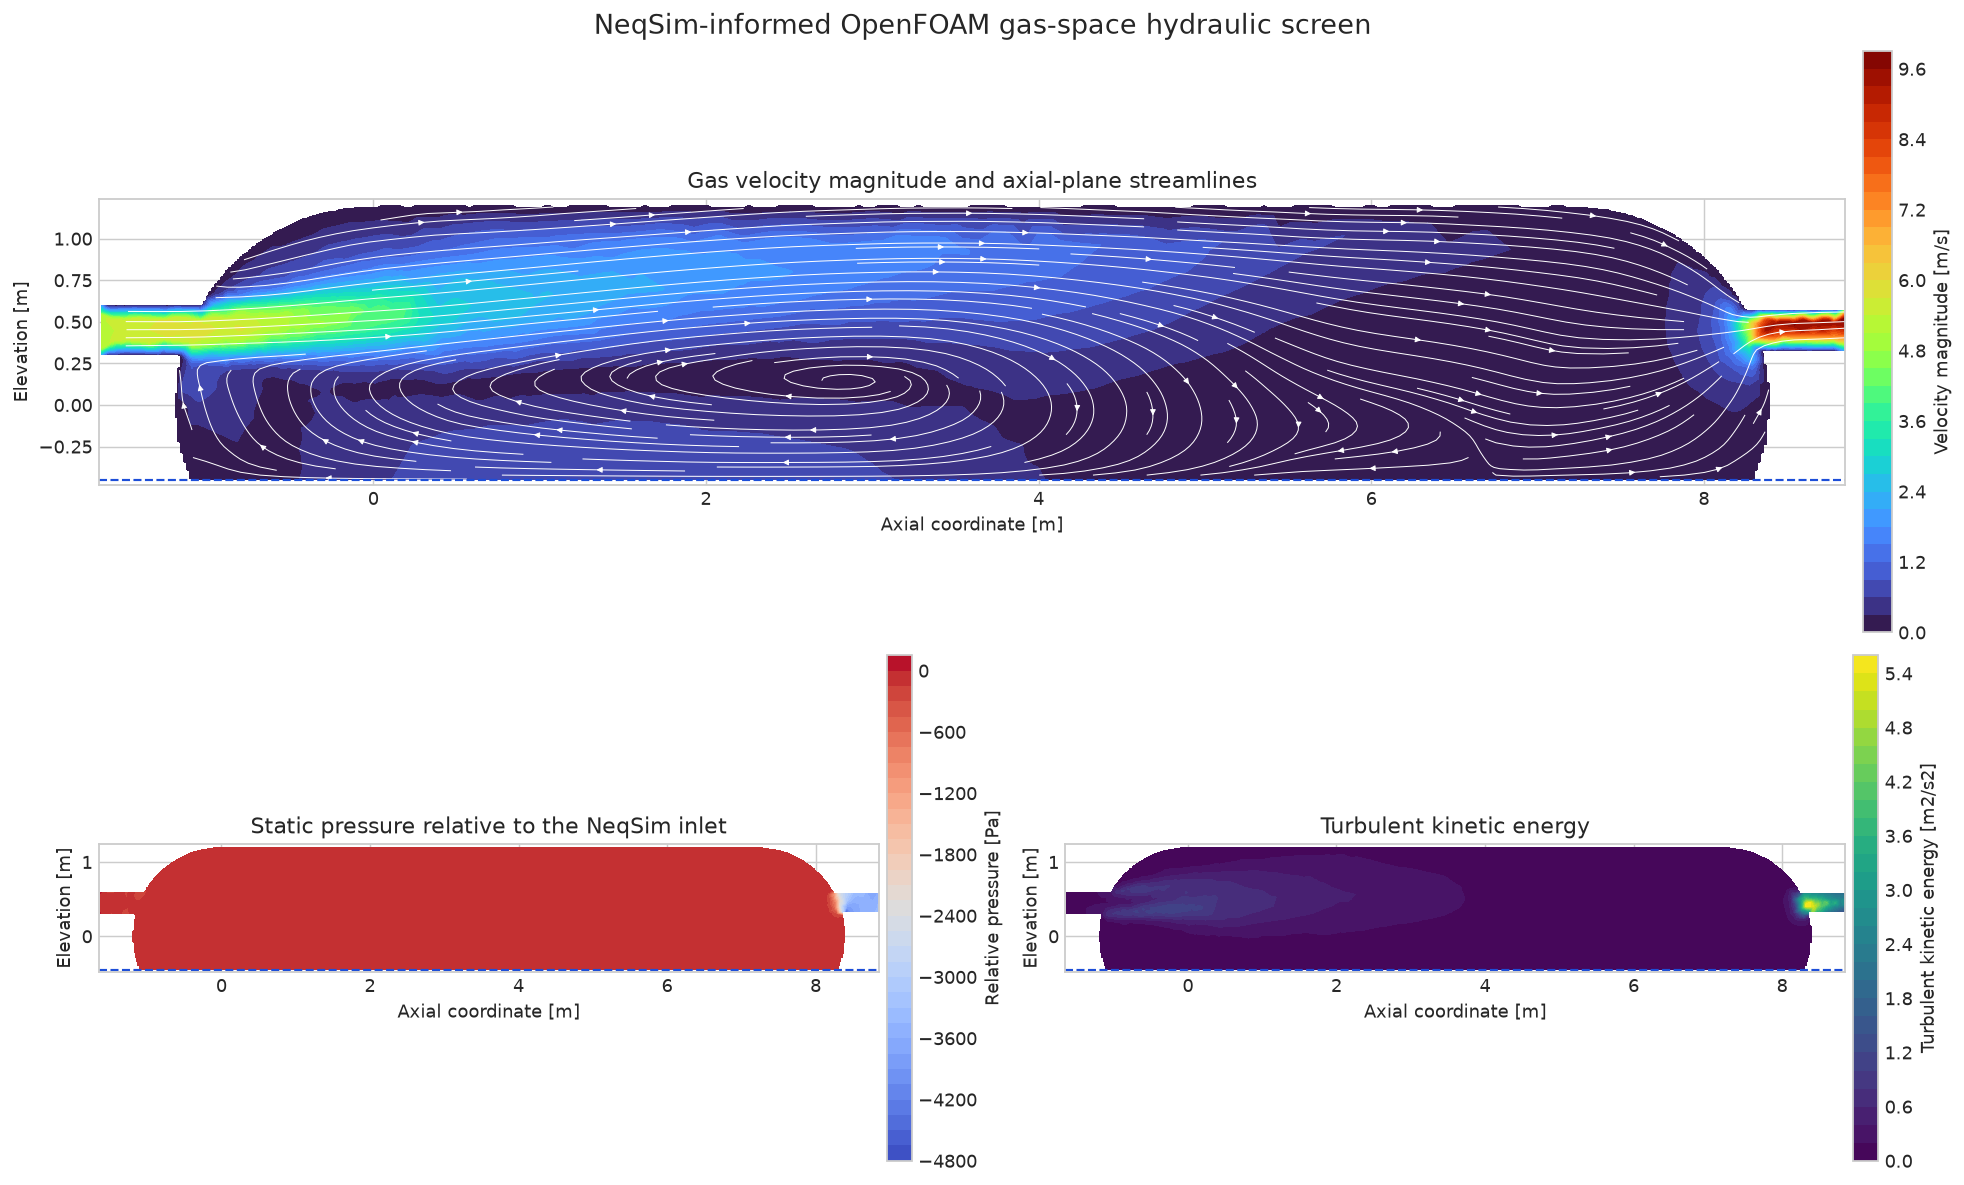

In [15]:
vtk_path = (
    CASE_DIR
    / "VTK"
    / f"{CASE_DIR.name}_{latest_time}.vtk"
)
solution_mesh = pv.read(vtk_path)

x_values_m = np.linspace(X_MIN_M, X_MAX_M, 620)
z_values_m = np.linspace(
    LIQUID_LEVEL_Z_M - 0.02,
    VESSEL_RADIUS_M + 0.03,
    210,
)
x_grid_m, z_grid_m = np.meshgrid(
    x_values_m,
    z_values_m,
)
sample_coordinates = np.column_stack(
    [
        x_grid_m.ravel(),
        np.zeros(x_grid_m.size),
        z_grid_m.ravel(),
    ]
)
sampled = pv.PolyData(sample_coordinates).sample(
    solution_mesh
)
valid_mask = sampled.point_data[
    "vtkValidPointMask"
].reshape(x_grid_m.shape).astype(bool)
velocity_vectors = sampled.point_data["U"].reshape(
    *x_grid_m.shape,
    3,
)
kinematic_pressure = sampled.point_data["p"].reshape(
    x_grid_m.shape
)
turbulent_k = sampled.point_data["k"].reshape(
    x_grid_m.shape
)

speed_m_per_s = np.linalg.norm(
    velocity_vectors,
    axis=2,
)
relative_pressure_pa = (
    gas_density_kg_per_m3
    * (
        kinematic_pressure
        - inlet_kinematic_pressure_m2_per_s2
    )
)
speed_field = np.ma.masked_where(
    ~valid_mask,
    speed_m_per_s,
)
pressure_field = np.ma.masked_where(
    ~valid_mask,
    relative_pressure_pa,
)
k_field = np.ma.masked_where(
    ~valid_mask,
    turbulent_k,
)
u_field = np.ma.masked_where(
    ~valid_mask,
    velocity_vectors[:, :, 0],
)
w_field = np.ma.masked_where(
    ~valid_mask,
    velocity_vectors[:, :, 2],
)


def draw_separator_outline(axis):
    axis.axhline(
        LIQUID_LEVEL_Z_M,
        color="#1d4ed8",
        linestyle="--",
        linewidth=1.2,
    )
    axis.set_xlim(X_MIN_M, X_MAX_M)
    axis.set_ylim(
        LIQUID_LEVEL_Z_M - 0.03,
        VESSEL_RADIUS_M + 0.04,
    )
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("Axial coordinate [m]")
    axis.set_ylabel("Elevation [m]")


figure = plt.figure(
    figsize=(15, 9),
    constrained_layout=True,
)
grid = figure.add_gridspec(
    2,
    2,
    height_ratios=[1.15, 1.0],
)

speed_axis = figure.add_subplot(grid[0, :])
speed_contours = speed_axis.contourf(
    x_values_m,
    z_values_m,
    speed_field,
    levels=36,
    cmap="turbo",
)
speed_axis.streamplot(
    x_values_m,
    z_values_m,
    u_field,
    w_field,
    color="white",
    density=(2.2, 1.2),
    linewidth=0.55,
    arrowsize=0.65,
)
draw_separator_outline(speed_axis)
speed_axis.set_title(
    "Gas velocity magnitude and axial-plane streamlines"
)
figure.colorbar(
    speed_contours,
    ax=speed_axis,
    label="Velocity magnitude [m/s]",
    pad=0.01,
)

pressure_axis = figure.add_subplot(grid[1, 0])
pressure_contours = pressure_axis.contourf(
    x_values_m,
    z_values_m,
    pressure_field,
    levels=36,
    cmap="coolwarm",
)
draw_separator_outline(pressure_axis)
pressure_axis.set_title(
    "Static pressure relative to the NeqSim inlet"
)
figure.colorbar(
    pressure_contours,
    ax=pressure_axis,
    label="Relative pressure [Pa]",
    pad=0.01,
)

k_axis = figure.add_subplot(grid[1, 1])
k_contours = k_axis.contourf(
    x_values_m,
    z_values_m,
    k_field,
    levels=36,
    cmap="viridis",
)
draw_separator_outline(k_axis)
k_axis.set_title("Turbulent kinetic energy")
figure.colorbar(
    k_contours,
    ax=k_axis,
    label="Turbulent kinetic energy [m2/s2]",
    pad=0.01,
)

figure.suptitle(
    "NeqSim-informed OpenFOAM gas-space hydraulic screen",
    fontsize=15,
)
plt.show()

## 16. Engineering interpretation and executable checks

The axial sample follows the nozzle elevation through the inlet jet and
outlet. The phase chart retains the NeqSim inlet split beside the CFD
interpretation. All acceptance checks are executable and stop publication
if geometry identity, convergence, conservation, or physical bounds fail.

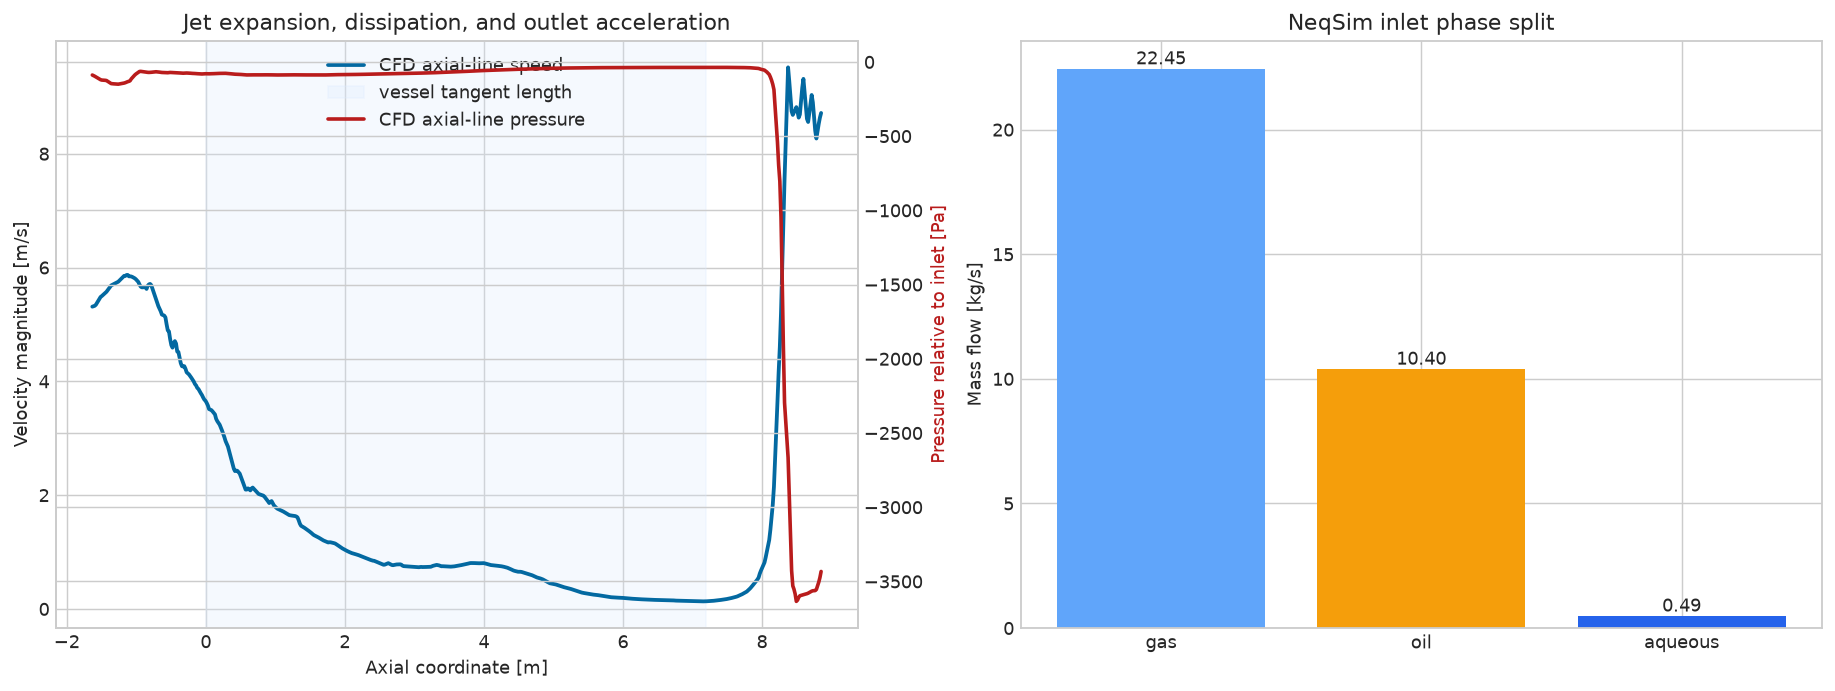

document/image diameter difference [%]      0.166667
NeqSim phases [-]                                  3
phase mass closure [%]                   1.79057e-12
CAD-Gmsh volume error [-]                 4.0964e-10
OpenFOAM mesh cells [-]                        47630
solver iterations [-]                            209
flow closure [%]                          0.00125036
gas pressure loss [Pa]                      3,432.82
nominal gas residence time [s]               78.4861
maximum speed [m/s]                          11.6611
maximum Mach number [-]                    0.0307327
all engineering checks passed                   True
Name: Final engineering validation, dtype: object

In [16]:
axial_coordinates = np.column_stack(
    [
        x_values_m,
        np.zeros_like(x_values_m),
        np.full_like(
            x_values_m,
            NOZZLE_CENTER_Z_M,
        ),
    ]
)
axial_sample = pv.PolyData(
    axial_coordinates
).sample(solution_mesh)
axial_valid = axial_sample.point_data[
    "vtkValidPointMask"
].astype(bool)
axial_speed_m_per_s = np.linalg.norm(
    axial_sample.point_data["U"],
    axis=1,
)
axial_pressure_pa = (
    gas_density_kg_per_m3
    * (
        axial_sample.point_data["p"]
        - inlet_kinematic_pressure_m2_per_s2
    )
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.2),
    constrained_layout=True,
)
profile_axis = axes[0]
pressure_axis = profile_axis.twinx()
profile_axis.plot(
    x_values_m[axial_valid],
    axial_speed_m_per_s[axial_valid],
    color="#0369a1",
    linewidth=2.1,
    label="CFD axial-line speed",
)
pressure_axis.plot(
    x_values_m[axial_valid],
    axial_pressure_pa[axial_valid],
    color="#b91c1c",
    linewidth=2.0,
    label="CFD axial-line pressure",
)
profile_axis.axvspan(
    0.0,
    TANGENT_LENGTH_M,
    color="#dbeafe",
    alpha=0.25,
    label="vessel tangent length",
)
profile_axis.set_xlabel("Axial coordinate [m]")
profile_axis.set_ylabel("Velocity magnitude [m/s]")
pressure_axis.set_ylabel(
    "Pressure relative to inlet [Pa]",
    color="#b91c1c",
)
profile_axis.set_title(
    "Jet expansion, dissipation, and outlet acceleration"
)
lines_1, labels_1 = profile_axis.get_legend_handles_labels()
lines_2, labels_2 = pressure_axis.get_legend_handles_labels()
profile_axis.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper center",
)

phase_axis = axes[1]
phase_colors = {
    "gas": "#60a5fa",
    "oil": "#f59e0b",
    "aqueous": "#2563eb",
}
phase_axis.bar(
    phase_table["phase"],
    phase_table["mass flow [kg/s]"],
    color=[
        phase_colors.get(phase_name, "#94a3b8")
        for phase_name in phase_table["phase"]
    ],
)
phase_axis.set_ylabel("Mass flow [kg/s]")
phase_axis.set_title("NeqSim inlet phase split")
for bar, mass_flow in zip(
    phase_axis.patches,
    phase_table["mass flow [kg/s]"],
):
    phase_axis.text(
        bar.get_x() + 0.5 * bar.get_width(),
        bar.get_height(),
        f"{mass_flow:.2f}",
        ha="center",
        va="bottom",
    )
plt.show()

maximum_speed_m_per_s = float(
    np.linalg.norm(
        solution_mesh.cell_data["U"],
        axis=1,
    ).max()
)
maximum_mach_number = (
    maximum_speed_m_per_s / gas_sound_speed_m_per_s
)
minimum_k = float(
    solution_mesh.cell_data["k"].min()
)
minimum_epsilon = float(
    solution_mesh.cell_data["epsilon"].min()
)

assert image_dimension_deviation_relative < 0.02
assert phase_mass_closure_relative < 1.0e-10
assert cad_gmsh_volume_error_relative < 1.0e-8
assert "Mesh OK." in mesh_check.stdout
assert convergence_match is not None
assert flow_closure_relative < 1.0e-3
assert mass_flow_difference_relative < 1.0e-3
assert minimum_k > 0.0
assert minimum_epsilon > 0.0
assert maximum_mach_number < 0.15
assert pressure_loss_pa > 0.0
assert nominal_gas_residence_time_s > 20.0
assert maximum_speed_m_per_s > ideal_inlet_velocity_m_per_s

final_summary = pd.Series(
    {
        "document/image diameter difference [%]": (
            100.0 * image_dimension_deviation_relative
        ),
        "NeqSim phases [-]": stream_fluid.getNumberOfPhases(),
        "phase mass closure [%]": (
            100.0 * phase_mass_closure_relative
        ),
        "CAD-Gmsh volume error [-]": (
            cad_gmsh_volume_error_relative
        ),
        "OpenFOAM mesh cells [-]": mesh_cell_count,
        "solver iterations [-]": solver_iterations,
        "flow closure [%]": 100.0 * flow_closure_relative,
        "gas pressure loss [Pa]": pressure_loss_pa,
        "nominal gas residence time [s]": (
            nominal_gas_residence_time_s
        ),
        "maximum speed [m/s]": maximum_speed_m_per_s,
        "maximum Mach number [-]": maximum_mach_number,
        "all engineering checks passed": True,
    },
    name="Final engineering validation",
)
final_summary

## 17. Package the reusable digital thread

The ZIP contains the reviewed design-basis JSON, exact STEP master, named
boundary STLs, Gmsh mesh, complete OpenFOAM case and logs, phase/coupling
tables, and solved VTK output.

In [17]:
phase_csv_path = RUNTIME_DIR / "neqsim_phase_split.csv"
phase_table.to_csv(
    phase_csv_path,
    index=False,
)
coupling_csv_path = (
    RUNTIME_DIR / "neqsim_openfoam_gas_coupling.csv"
)
coupling_table.to_csv(
    coupling_csv_path,
    header=["value"],
)

archive_base = (
    RUNTIME_PARENT
    / "pid_datasheet_neqsim_cad_cfd_workflow"
)
archive_path = Path(
    shutil.make_archive(
        str(archive_base),
        "zip",
        root_dir=RUNTIME_DIR,
    )
)

artifact_table = pd.DataFrame(
    [
        {
            "artifact": DESIGN_BASIS_PATH.name,
            "purpose": "reviewed document-to-model contract",
            "size [kB]": (
                DESIGN_BASIS_PATH.stat().st_size / 1_024.0
            ),
        },
        {
            "artifact": STEP_PATH.name,
            "purpose": "exact editable CAD master",
            "size [kB]": STEP_PATH.stat().st_size / 1_024.0,
        },
        {
            "artifact": MSH_PATH.name,
            "purpose": "named Gmsh volume mesh",
            "size [kB]": MSH_PATH.stat().st_size / 1_024.0,
        },
        {
            "artifact": archive_path.name,
            "purpose": "complete reusable digital thread",
            "size [kB]": archive_path.stat().st_size / 1_024.0,
        },
    ]
)
display(artifact_table)

try:
    from IPython.display import FileLink

    display(
        FileLink(
            archive_path,
            result_html_prefix="Download: ",
        )
    )
except ImportError:
    print(f"Archive: {archive_path}")

,artifact,purpose,size [kB]
0,engineering_design_basis.json,reviewed document-to-model contract,1.5293
1,20-VG-001_gas_space.step,exact editable CAD master,53.3037
2,20-VG-001_gas_space.msh,named Gmsh volume mesh,"2,189.1"
3,pid_datasheet_neqsim_cad_cfd_workflow.zip,complete reusable digital thread,"7,032.02"


/workspace/scratch/414b0104c46c/pid_datasheet_neqsim_cad_cfd_workflow.zip

## Conclusions, limitations, and next steps

This example preserves the same tags and approved values from the P&ID and
datasheets through NeqSim, CadQuery, Gmsh, and OpenFOAM. The solved model
provides a defensible gas-space hydraulic screen, not a separator-efficiency
prediction.

Important production extensions are:

- reconstruct the real approved head geometry, internals, nozzle angles, and
  weld transitions;
- use perspective-corrected photogrammetry or laser scans when documents are
  incomplete;
- add wall prism layers and perform mesh and turbulence-model sensitivity;
- use a multiphase solver for liquid levels, droplets, waves, carryover, and
  carryunder;
- validate residence-time distributions and separation performance against
  plant, vendor, or experimental data; and
- fit validated CFD response surfaces back into a composable NeqSim separator
  or process model.

The synthetic values and educational correlations must not be used for
equipment qualification or safety-critical design.